# Notebook 01 -- Data Preparation and Feature Engineering

**Objective**: Load raw datasets, validate schema, aggregate session-level interaction logs, engineer synthetic feedback sentiment, merge all sources into a single modeling table, and export to artifacts.

**Colab Paths**:
- `/content/student_dropout_dataset_v3.csv`
- `/content/student_learning_interaction_dataset.csv`
- `/content/college_student_management_data.csv`

**Output**: `/content/artifacts/engineered_features.csv`

In [1]:
# ── Section 1: Configuration and Paths ──────────────────────────────────────────
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 42

# Dataset paths — relative to this notebook's location (notebooks/)
DATA_DIR           = Path("../data")
DROPOUT_PATH       = DATA_DIR / "student_dropout_dataset_v3.csv"
INTERACTION_PATH   = DATA_DIR / "student_learning_interaction_dataset.csv"
MANAGEMENT_PATH    = DATA_DIR / "college_student_management_data.csv"

# Output directory
ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Dropout dataset exists       :", DROPOUT_PATH.exists())
print("Interaction dataset exists    :", INTERACTION_PATH.exists())
print("Management dataset exists     :", MANAGEMENT_PATH.exists())
print("Artifacts directory           :", ARTIFACTS_DIR.resolve())

Dropout dataset exists       : False
Interaction dataset exists    : False
Management dataset exists     : False
Artifacts directory           : /artifacts


In [2]:
import pandas as pd
import numpy as np

dropout_df      = pd.read_csv(DROPOUT_PATH)
interaction_df  = pd.read_csv(INTERACTION_PATH)
management_df   = pd.read_csv(MANAGEMENT_PATH)

print("Dropout dataset       :", dropout_df.shape)
print("Interaction dataset   :", interaction_df.shape)
print("Management dataset    :", management_df.shape)

dropout_df.head(3)

FileNotFoundError: [Errno 2] No such file or directory: '../data/student_dropout_dataset_v3.csv'

## Section 3: Schema Validation

Verify that required columns exist and that target/label columns have expected value ranges.

In [5]:
# Validate dropout dataset
required_dropout_cols = [
    "Student_ID", "Age", "Gender", "Family_Income", "Internet_Access",
    "Study_Hours_per_Day", "Attendance_Rate", "Assignment_Delay_Days",
    "Travel_Time_Minutes", "Part_Time_Job", "Scholarship", "Stress_Index",
    "GPA", "Semester_GPA", "CGPA", "Semester", "Department",
    "Parental_Education", "Dropout"
]
missing_cols = set(required_dropout_cols) - set(dropout_df.columns)
assert len(missing_cols) == 0, f"Missing columns in dropout dataset: {missing_cols}"

# Validate target column
assert dropout_df["Dropout"].isin([0, 1]).all(), "Dropout column must be binary (0/1)"
print("Dropout target distribution:")
print(dropout_df["Dropout"].value_counts())
print(f"\nDropout rate: {dropout_df['Dropout'].mean():.2%}")

# Validate interaction dataset
required_interaction_cols = [
    "student_id", "session_id", "time_spent_minutes", "pages_visited",
    "video_watched_percent", "click_events", "attention_score",
    "days_since_last_activity", "success_label"
]
missing_inter = set(required_interaction_cols) - set(interaction_df.columns)
assert len(missing_inter) == 0, f"Missing columns in interaction dataset: {missing_inter}"
print(f"\nInteraction records: {len(interaction_df)}")
print(f"Unique students in interactions: {interaction_df['student_id'].nunique()}")

Dropout target distribution:
Dropout
0    7646
1    2354
Name: count, dtype: int64

Dropout rate: 23.54%

Interaction records: 9000
Unique students in interactions: 300


## Section 4: Missing Value Report

Quantify missingness per column across both primary datasets before any imputation.

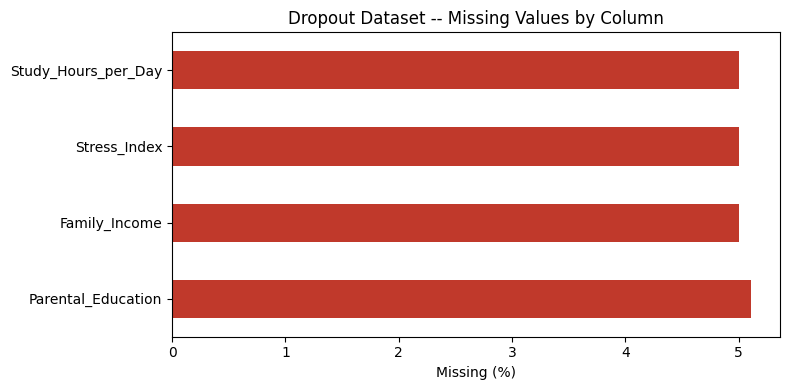

Parental_Education     5.11
Family_Income          5.00
Stress_Index           5.00
Study_Hours_per_Day    5.00


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dropout dataset missingness
dropout_missing = (dropout_df.isna().sum() / len(dropout_df) * 100).sort_values(ascending=False)
dropout_missing = dropout_missing[dropout_missing > 0]

if len(dropout_missing) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    dropout_missing.plot.barh(ax=ax, color="#c0392b")
    ax.set_xlabel("Missing (%)")
    ax.set_title("Dropout Dataset -- Missing Values by Column")
    plt.tight_layout()
    plt.show()
    print(dropout_missing.to_string())
else:
    print("No missing values in dropout dataset.")

## Section 5: Interaction Log Aggregation

The interaction dataset contains session-level records per student. We aggregate these into per-student behavioural signals that serve as disengagement indicators:

- **session_count**: total learning sessions recorded
- **avg_time_spent_minutes**: mean time per session
- **avg_pages_visited**: mean pages per session
- **avg_video_watched_percent**: mean video completion rate
- **avg_click_events**: mean click activity
- **avg_attention_score**: mean computed attention metric
- **avg_days_since_last_activity**: mean gap between sessions
- **success_rate**: proportion of sessions labeled successful

In [7]:
# Map student_id format "S0001" -> numeric 1 for merge with dropout Student_ID
interaction_df["student_num"] = (
    interaction_df["student_id"].str.replace("S", "", regex=False).astype(int)
)

interaction_agg = (
    interaction_df.groupby("student_num", as_index=False)
    .agg(
        session_count                = ("session_id", "count"),
        avg_time_spent_minutes       = ("time_spent_minutes", "mean"),
        avg_pages_visited            = ("pages_visited", "mean"),
        avg_video_watched_percent    = ("video_watched_percent", "mean"),
        avg_click_events             = ("click_events", "mean"),
        avg_attention_score          = ("attention_score", "mean"),
        avg_days_since_last_activity = ("days_since_last_activity", "mean"),
        success_rate                 = ("success_label", "mean"),
    )
)

print("Aggregated interaction features shape:", interaction_agg.shape)
interaction_agg.head()

Aggregated interaction features shape: (300, 9)


,student_num,session_count,avg_time_spent_minutes,avg_pages_visited,avg_video_watched_percent,avg_click_events,avg_attention_score,avg_days_since_last_activity,success_rate
0,1,30,31.633261,6.600000,69.477835,28.033333,0.187333,4.933333,0.800000
1,2,30,29.128378,8.800000,73.184174,30.233333,0.197000,4.133333,0.800000
2,3,30,31.174898,7.800000,73.102170,29.300000,0.208000,4.433333,0.733333
3,4,30,30.234982,8.466667,70.819325,27.400000,0.198000,4.366667,0.766667
4,5,30,26.841076,8.200000,66.091257,31.766667,0.169333,4.400000,0.766667


## Section 6: Synthetic Feedback and Sentiment Score

The problem statement requires sentiment analysis from feedback forms. Since real feedback text is unavailable, we engineer synthetic feedback from the `Stress_Index` column and derive a numeric `sentiment_score`.

**Mapping logic**:
- Stress >= 7.5: strongly negative feedback
- Stress >= 5.0: moderately negative feedback
- Stress < 5.0: positive feedback
- Missing stress: neutral/ambiguous feedback

The sentiment score is computed using keyword matching and ranges from -1.0 (negative) to +1.0 (positive).

In [8]:
def feedback_from_stress(stress):
    """Generate synthetic student feedback text from numeric stress index."""
    if pd.isna(stress):
        return "I am managing, but I need occasional support."
    if stress >= 7.5:
        return "I feel overwhelmed with deadlines and cannot keep up with coursework."
    if stress >= 5.0:
        return "I am under pressure and struggling to balance studies."
    return "I feel confident and on track with my learning goals."


def sentiment_from_feedback(text):
    """Compute a sentiment polarity score from feedback text using keyword matching."""
    text_lower = text.lower()
    negative_words = ["overwhelmed", "struggling", "cannot", "pressure"]
    positive_words = ["confident", "on track", "goals", "managing"]
    score = 0
    for w in negative_words:
        if w in text_lower:
            score -= 1
    for w in positive_words:
        if w in text_lower:
            score += 1
    return float(np.clip(score / 4, -1, 1))


# Apply to dropout dataset
dropout_df["synthetic_feedback"] = dropout_df["Stress_Index"].apply(feedback_from_stress)
dropout_df["sentiment_score"]    = dropout_df["synthetic_feedback"].apply(sentiment_from_feedback)

# Show distribution
print("Sentiment score distribution:")
print(dropout_df["sentiment_score"].value_counts().sort_index())
print("\nSample feedback texts:")
dropout_df[["Student_ID", "Stress_Index", "synthetic_feedback", "sentiment_score"]].sample(5, random_state=RANDOM_SEED)

Sentiment score distribution:
sentiment_score
-0.50    5918
 0.25     500
 0.75    3582
Name: count, dtype: int64

Sample feedback texts:


,Student_ID,Stress_Index,synthetic_feedback,sentiment_score
6252,6253,NaN,"I am managing, but I need occasional support.",0.25
4684,4685,NaN,"I am managing, but I need occasional support.",0.25
1731,1732,NaN,"I am managing, but I need occasional support.",0.25
4742,4743,NaN,"I am managing, but I need occasional support.",0.25
4521,4522,NaN,"I am managing, but I need occasional support.",0.25


## Section 7: Merge All Sources

Left-join the aggregated interaction features onto the dropout dataset using Student_ID. Students without interaction records will have NaN for interaction columns (handled in imputation).

In [9]:
# Merge dropout + interaction aggregates
merged_df = dropout_df.merge(
    interaction_agg,
    left_on="Student_ID",
    right_on="student_num",
    how="left",
).drop(columns=["student_num"], errors="ignore")

print("Merged dataset shape:", merged_df.shape)
print("Columns:", list(merged_df.columns))

Merged dataset shape: (10000, 29)
Columns: ['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department', 'Parental_Education', 'Dropout', 'synthetic_feedback', 'sentiment_score', 'session_count', 'avg_time_spent_minutes', 'avg_pages_visited', 'avg_video_watched_percent', 'avg_click_events', 'avg_attention_score', 'avg_days_since_last_activity', 'success_rate']


## Section 8: Missing Value Imputation

Strategy:
- **Numeric columns**: fill with column median (robust to outliers).
- **Categorical columns**: fill with the string "Unknown".

In [10]:
# Separate column types
numeric_cols     = merged_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = merged_df.select_dtypes(exclude=[np.number]).columns.tolist()

# Impute
for col in numeric_cols:
    merged_df[col] = merged_df[col].fillna(merged_df[col].median())
for col in categorical_cols:
    merged_df[col] = merged_df[col].fillna("Unknown")

# Verify: zero missing values
assert merged_df.isna().sum().sum() == 0, "Imputation incomplete"
print("Missing values after imputation: 0")

Missing values after imputation: 0


## Section 9: Exploratory Data Analysis

Key distribution plots for the target variable and the most relevant behavioural features.

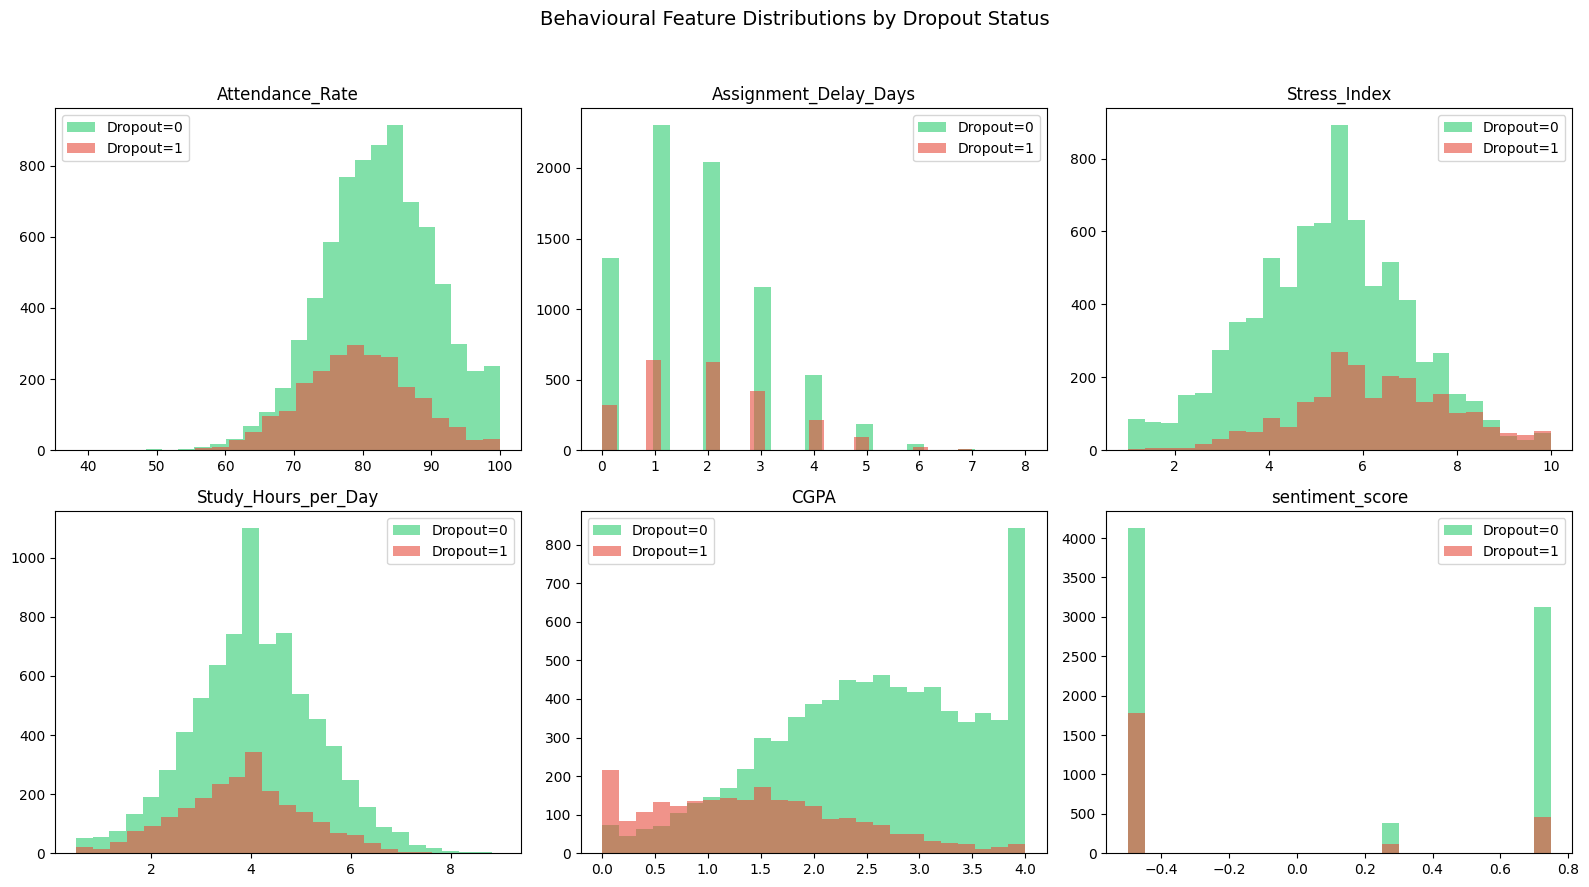

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Behavioural Feature Distributions by Dropout Status", fontsize=14)

plot_features = [
    "Attendance_Rate", "Assignment_Delay_Days", "Stress_Index",
    "Study_Hours_per_Day", "CGPA", "sentiment_score",
]

for ax, feat in zip(axes.flat, plot_features):
    for label, color in [(0, "#2ecc71"), (1, "#e74c3c")]:
        subset = merged_df[merged_df["Dropout"] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, label=f"Dropout={label}", color=color)
    ax.set_title(feat)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

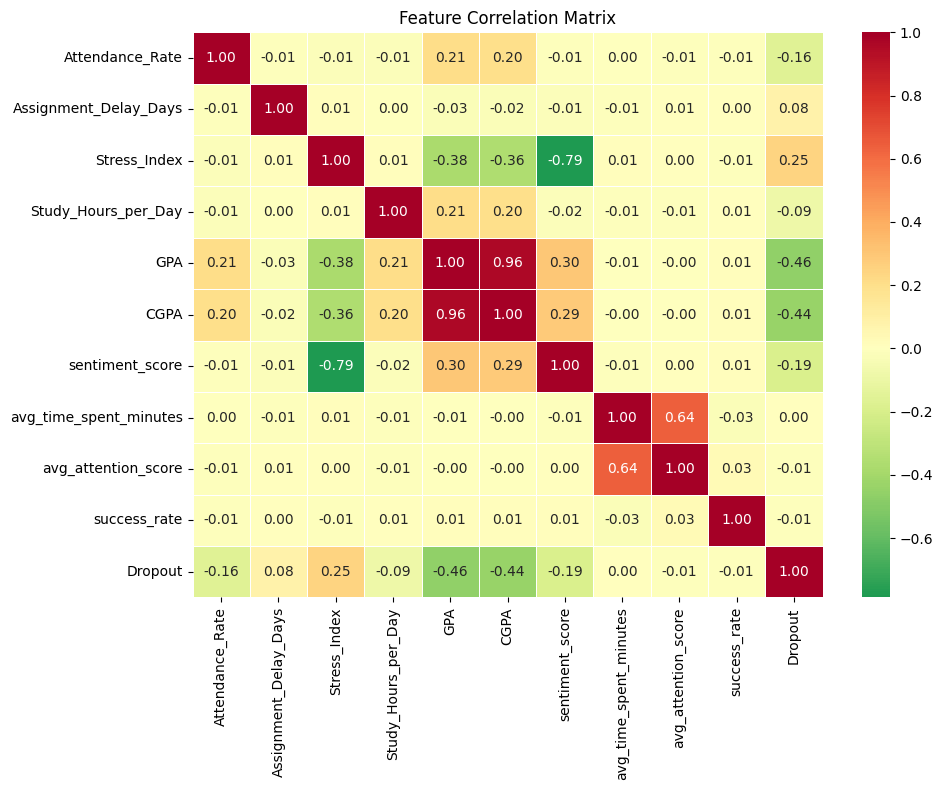

In [12]:
# Correlation heatmap for numeric features
corr_cols = [
    "Attendance_Rate", "Assignment_Delay_Days", "Stress_Index",
    "Study_Hours_per_Day", "GPA", "CGPA", "sentiment_score",
    "avg_time_spent_minutes", "avg_attention_score", "success_rate", "Dropout",
]
existing_corr_cols = [c for c in corr_cols if c in merged_df.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    merged_df[existing_corr_cols].corr(),
    annot=True, fmt=".2f", cmap="RdYlGn_r", center=0, ax=ax,
    linewidths=0.5,
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Section 10: Data Card and Export

Final summary of the engineered dataset before saving to artifacts.

In [13]:
# Data card
num_features = merged_df.select_dtypes(include=[np.number]).columns.tolist()
cat_features = merged_df.select_dtypes(exclude=[np.number]).columns.tolist()

print("=" * 60)
print("DATA CARD -- Engineered Feature Table")
print("=" * 60)
print(f"  Rows              : {len(merged_df)}")
print(f"  Total columns     : {len(merged_df.columns)}")
print(f"  Numeric features  : {len(num_features)}")
print(f"  Categorical cols  : {len(cat_features)}")
print(f"  Target column     : Dropout")
print(f"  Target balance    : {dict(merged_df['Dropout'].value_counts())}")
print(f"  Missing values    : {merged_df.isna().sum().sum()}")
print("=" * 60)

# Engineered features explicitly
engineered = [
    "synthetic_feedback", "sentiment_score",
    "session_count", "avg_time_spent_minutes", "avg_pages_visited",
    "avg_video_watched_percent", "avg_click_events", "avg_attention_score",
    "avg_days_since_last_activity", "success_rate",
]
present = [c for c in engineered if c in merged_df.columns]
print(f"\nEngineered features ({len(present)}):")
for f in present:
    print(f"  - {f}")

DATA CARD -- Engineered Feature Table
  Rows              : 10000
  Total columns     : 29
  Numeric features  : 21
  Categorical cols  : 8
  Target column     : Dropout
  Target balance    : {0: np.int64(7646), 1: np.int64(2354)}
  Missing values    : 0

Engineered features (10):
  - synthetic_feedback
  - sentiment_score
  - session_count
  - avg_time_spent_minutes
  - avg_pages_visited
  - avg_video_watched_percent
  - avg_click_events
  - avg_attention_score
  - avg_days_since_last_activity
  - success_rate


In [14]:
# Export engineered dataset
output_path = ARTIFACTS_DIR / "engineered_features.csv"
merged_df.to_csv(output_path, index=False)
print(f"Exported: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")

merged_df.head()

Exported: /content/artifacts/engineered_features.csv
File size: 2445.4 KB


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,...,synthetic_feedback,sentiment_score,session_count,avg_time_spent_minutes,avg_pages_visited,avg_video_watched_percent,avg_click_events,avg_attention_score,avg_days_since_last_activity,success_rate
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,...,I am under pressure and struggling to balance ...,-0.50,30.0,31.633261,6.600000,69.477835,28.033333,0.187333,4.933333,0.800000
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,...,I am under pressure and struggling to balance ...,-0.50,30.0,29.128378,8.800000,73.184174,30.233333,0.197000,4.133333,0.800000
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,...,I am under pressure and struggling to balance ...,-0.50,30.0,31.174898,7.800000,73.102170,29.300000,0.208000,4.433333,0.733333
3,4,24.4,Male,29740.5,Yes,4.00,82.2,2,38.6,No,...,"I am managing, but I need occasional support.",0.25,30.0,30.234982,8.466667,70.819325,27.400000,0.198000,4.366667,0.766667
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,...,I am under pressure and struggling to balance ...,-0.50,30.0,26.841076,8.200000,66.091257,31.766667,0.169333,4.400000,0.766667
